# XGBoost Derivation

In [1]:
# =============================================================================
# Cell 1: Notebook Preamble and Imports
# =============================================================================
# ---
# # Notebook: SHAP Analysis for XGBoost Model
#
# **Objective:**
# This notebook trains an XGBoost model using the specific hyperparameters
# from the benchmarking script, saves the model, and then calculates SHAP values
# for the entire test set using the fast `shap.TreeExplainer`.
# ---

import os
import time
import pandas as pd
import numpy as np
import pickle
import shutil

import xgboost as xgb
from sklearn.model_selection import train_test_split
# Keeping import for compatibility with loaded models
from sklearn.preprocessing import StandardScaler
import shap

# Set SHAP to use a javascript-based plotting method for notebooks
shap.initjs()

print("Libraries imported successfully.")


# =============================================================================
# Cell 2: Configuration and Paths
# =============================================================================
# --- Configuration ---
TARGET = 'aki_boolean'
RANDOM_STATE = 42

# --- File Paths ---
# PLEASE UPDATE these paths to match your system
BASE_DATA_DIR = '/home/server/Projects/data/AKI/'
# Using a separate directory for XGBoost results to keep things organized
RESULTS_DIR = '/home/server/Projects/data/AKI/results/xgboost_analysis/'

# Create the results directory if it doesn't exist
os.makedirs(RESULTS_DIR, exist_ok=True)

# Path to the source data
DATA_PATH = os.path.join(BASE_DATA_DIR, 'tabular_combined.csv')
NORMALIZATION_STATS_PATH = '/home/server/Projects/data/base/normalization_stats.csv'

# Paths for saving the trained model and the final SHAP values
MODEL_PATH = os.path.join(RESULTS_DIR, 'xgboost_model.json')
SHAP_VALUES_PATH = os.path.join(RESULTS_DIR, 'shap_explanation.pkl')
SHAP_VALUES_DENORM_PATH = os.path.join(RESULTS_DIR, 'shap_explanation_denorm.pkl')
SHAP_VALUES_PROB_PATH = os.path.join(RESULTS_DIR, 'shap_explanation_prob.pkl')


print(f"Results will be saved in: {RESULTS_DIR}")


# =============================================================================
# Cell 3: Load Hyperparameters for the 'combined' Dataset
# =============================================================================
# These are the optimized hyperparameters for XGBoost on the 'combined' dataset
# from your original benchmarking script.
hpo_params_combined = {
    'xgb': {
        'n_estimators': 1110,
        'learning_rate': 0.0172,
        'max_depth': 9,
        'subsample': 0.8281,
        'colsample_bytree': 0.7827,
        'gamma': 1.7456
    }
}
xgb_params = hpo_params_combined['xgb']
print("XGBoost hyperparameters loaded:")
print(xgb_params)


# =============================================================================
# Cell 4: Load and Split Data
# =============================================================================
print(f"\nLoading data from {DATA_PATH}...")
try:
    df = pd.read_csv(DATA_PATH)
except FileNotFoundError:
    print(f"ERROR: Data file not found at {DATA_PATH}")
    print("Please update the BASE_DATA_DIR variable in Cell 2.")
    df = pd.DataFrame()

if not df.empty:
    if 'op_id' in df.columns:
        df = df.drop(columns=['op_id'])

    print("Performing an 80/20 stratified train/test split...")
    train_df, test_df = train_test_split(
        df,
        test_size=0.2,
        stratify=df[TARGET],
        random_state=RANDOM_STATE
    )
    
    # Separate features (X) from the target (y)
    X_train_raw = train_df.drop(columns=[TARGET])
    y_train = train_df[TARGET]
    X_test_raw = test_df.drop(columns=[TARGET])
    y_test = test_df[TARGET]

    print(f"Training data shape: {X_train_raw.shape}")
    print(f"Test data shape: {X_test_raw.shape}")


# =============================================================================
# Cell 5: Preprocess Data (Type Conversion Only, No Scaling)
# =============================================================================
# Simply ensure data is numeric without scaling
if not df.empty:
    print("\n--- Preparing Data (No Scaling) ---")
    
    # Convert to numpy arrays and ensure float type for SHAP/XGBoost compatibility
    X_train_scaled = X_train_raw.values.astype(np.float64)
    X_test_scaled = X_test_raw.values.astype(np.float64)
    
    # For creating the final SHAP explanation, it's useful to have these as DataFrames
    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_raw.columns)
    X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test_raw.columns)

    print("Data prepared for training (converted to float64, no scaling applied).")


# =============================================================================
# Cell 6: Train or Load the XGBoost Model
# =============================================================================
if not df.empty:
    if os.path.exists(MODEL_PATH):
        print(f"\nFound existing model. Loading from: {MODEL_PATH}")
        model = xgb.XGBClassifier()
        model.load_model(MODEL_PATH)
        print("Model loaded successfully.")
    else:
        print(f"\nNo existing model found. Training a new XGBoost model...")
        
        # Calculate the scale_pos_weight for handling class imbalance, same as the benchmark script
        scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1) if np.sum(y_train == 1) > 0 else 1
        print(f"Calculated scale_pos_weight for class imbalance: {scale_pos_weight:.2f}")

        # --- FIX IS HERE ---
        # The `early_stopping_rounds` parameter is now part of the constructor.
        model = xgb.XGBClassifier(
            **xgb_params,
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1, # Use all available CPU cores
            early_stopping_rounds=50  # MOVED TO HERE
        )

        print("Starting model training...")
        # And it is removed from the .fit() method call below.
        model.fit(X_train_scaled, y_train, eval_set=[(X_test_scaled, y_test)], verbose=False)
        print("Model training complete.")
        
        # Save the model using its native, recommended format
        model.save_model(MODEL_PATH)
        print(f"Model saved to {MODEL_PATH}")

    print("\n--- Model Object ---")
    print(model)


# =============================================================================
# Cell 7: Calculate and Save SHAP Values
# =============================================================================
if not df.empty:
    if os.path.exists(SHAP_VALUES_PATH):
        print(f"\nLoading pre-calculated SHAP values from: {SHAP_VALUES_PATH}")
        with open(SHAP_VALUES_PATH, 'rb') as f:
            shap_explanation = pickle.load(f)
        print("SHAP values loaded successfully.")
    else:
        print("\n--- Calculating SHAP values using TreeExplainer ---")
        
        explainer = shap.TreeExplainer(model)
        
        print(f"Starting SHAP calculation for {len(X_test_scaled)} samples at {time.ctime()}...")
        # Note: We pass the numpy array for performance, but will use the DataFrame for the explanation object
        shap_values_raw = explainer.shap_values(X_test_scaled)
        print(f"SHAP calculation finished at {time.ctime()}.")

        # Create a modern SHAP Explanation object
        shap_explanation = shap.Explanation(
            values=shap_values_raw,
            base_values=explainer.expected_value,
            data=X_test_scaled_df, # Use the DataFrame here
            feature_names=X_test_scaled_df.columns.tolist()
        )
        
        print("\nSaving SHAP Explanation object...")
        with open(SHAP_VALUES_PATH, 'wb') as f:
            pickle.dump(shap_explanation, f)
        print(f"SHAP values saved to: {SHAP_VALUES_PATH}")

    print("\n--- SHAP Explanation Object Summary ---")
    print(f"SHAP values shape: {shap_explanation.values.shape}")
    print(f"Data shape: {shap_explanation.data.shape}")


# =============================================================================
# Cell 8: Calculate SHAP Explainer with Denormalized Data
# =============================================================================
# Use the same logic as before to explain SHAP values for denormalized data.
if not df.empty:
    if os.path.exists(SHAP_VALUES_DENORM_PATH):
        print(f"\nLoading pre-calculated SHAP values from: {SHAP_VALUES_DENORM_PATH}")
        with open(SHAP_VALUES_DENORM_PATH, 'rb') as f:
            shap_explanation = pickle.load(f)
        print("SHAP values loaded successfully.")
    else:
        print("\n--- Calculating SHAP explanation using denormalized data ---")
        
        # 1. Load normalization stats
        # TODO: df_stats only contains some features (because not everything was initially normalized).
        df_stats = pd.read_csv(NORMALIZATION_STATS_PATH)
        df_stats = df_stats.set_index('Unnamed: 0')
        if 'std' not in df_stats.columns:
            df_stats['std'] = np.sqrt(df_stats['var'])
        
        # 2. Load SHAP values from previous calculation
        with open(SHAP_VALUES_PATH, 'rb') as f:
            shap_explanation = pickle.load(f)
        shap_values_raw = shap_explanation.values
        print("Previous SHAP values loaded successfully.")

        # 3. Denormalize the data for the raw shap values
        print("Denormalizing data for calculating shap explanation")
        features_to_unnormalize = list(set(df_stats.index) & set(shap_explanation.feature_names))
        feature_indices = [shap_explanation.feature_names.index(f) for f in features_to_unnormalize]
        data_unnorm = shap_explanation.data.to_numpy()
        for i, feature in zip(feature_indices, features_to_unnormalize):
            mean = df_stats.loc[feature, 'mean']
            std = df_stats.loc[feature, 'std']
            data_unnorm[:, i] = data_unnorm[:, i] * std + mean

        # 4. Calculate new shap explanation for denormalized values
        shap_explanation_denorm = shap.Explanation(
            values=shap_values_raw,
            base_values=shap_explanation.base_values,
            data=data_unnorm, # Use the denormed data
            feature_names=shap_explanation.feature_names
        )
        
        print("\nSaving denormalized SHAP Explanation object...")
        with open(SHAP_VALUES_DENORM_PATH, 'wb') as f:
            pickle.dump(shap_explanation_denorm, f)
        print(f"SHAP values saved to: {SHAP_VALUES_DENORM_PATH}")


# =============================================================================
# Cell 9: Calculate SHAP Explainer with Denormalized Data and Probability Output
# =============================================================================
#TODO(justin): you might wanna clean this up lol
# Use the same logic as before to explain SHAP values for denormalized data.
# If normalization_stats.csv is not available, run create_base.py again in data_preoprocessing
if not df.empty:
    if os.path.exists(SHAP_VALUES_PROB_PATH):
        print(f"\nLoading pre-calculated SHAP values from: {SHAP_VALUES_PROB_PATH}")
        with open(SHAP_VALUES_PROB_PATH, 'rb') as f:
            shap_explanation = pickle.load(f)
        print("SHAP values loaded successfully.")
    else:
        print("\n--- Calculating SHAP explanation using denormalized data and probability output ---")

        print("\n--- Calculating SHAP values using TreeExplainer ---")
        
        # Fix: Convert data to float32 for SHAP compatibility
        explainer = shap.TreeExplainer(
            model, 
            model_output='probability',
            data=X_test_scaled[:500].astype(np.float32)  # Ensure float32 type for SHAP
        )
        
        print(f"Starting SHAP calculation for {len(X_test_scaled)} samples at {time.ctime()}...")
        # Note: We pass the numpy array for performance, but will use the DataFrame for the explanation object
        shap_values_raw = explainer.shap_values(X_test_scaled.astype(np.float32))
        print(f"SHAP calculation finished at {time.ctime()}.")

        # Create a modern SHAP Explanation object
        shap_explanation = shap.Explanation(
            values=shap_values_raw,
            base_values=explainer.expected_value,
            data=X_test_scaled_df, # Use the DataFrame here
            feature_names=X_test_scaled_df.columns.tolist()
        )
        
        # 1. Load normalization stats
        # TODO: df_stats only contains some features (because not everything was initially normalized).
        df_stats = pd.read_csv(NORMALIZATION_STATS_PATH)
        df_stats = df_stats.set_index('Unnamed: 0')
        if 'std' not in df_stats.columns:
            df_stats['std'] = np.sqrt(df_stats['var'])
        
        # 2. Load SHAP values from previous calculation
        shap_values_raw = shap_explanation.values
        print("Probability SHAP values loaded successfully.")

        # 3. Denormalize the data for the raw shap values
        print("Denormalizing data for calculating shap explanation")
        features_to_unnormalize = list(set(df_stats.index) & set(shap_explanation.feature_names))
        feature_indices = [shap_explanation.feature_names.index(f) for f in features_to_unnormalize]
        data_unnorm = shap_explanation.data.to_numpy()
        for i, feature in zip(feature_indices, features_to_unnormalize):
            mean = df_stats.loc[feature, 'mean']
            std = df_stats.loc[feature, 'std']
            data_unnorm[:, i] = data_unnorm[:, i] * std + mean

        # 4. Calculate new shap explanation for denormalized values
        shap_explanation_prob = shap.Explanation(
            values=shap_values_raw,
            base_values=shap_explanation.base_values,
            data=data_unnorm, # Use the denormed data
            feature_names=shap_explanation.feature_names
        )
        
        print("\nSaving denormalized SHAP Explanation object...")
        with open(SHAP_VALUES_PROB_PATH, 'wb') as f:
            pickle.dump(shap_explanation_prob, f)
        print(f"SHAP values saved to: {SHAP_VALUES_PROB_PATH}")

/home/server/Projects/VitalDB-Dimensionality-Reduction/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully.
Results will be saved in: /home/server/Projects/data/AKI/results/xgboost_analysis/
XGBoost hyperparameters loaded:
{'n_estimators': 1110, 'learning_rate': 0.0172, 'max_depth': 9, 'subsample': 0.8281, 'colsample_bytree': 0.7827, 'gamma': 1.7456}

Loading data from /home/server/Projects/data/AKI/tabular_combined.csv...
Performing an 80/20 stratified train/test split...
Training data shape: (48088, 274)
Test data shape: (12022, 274)

--- Preparing Data (No Scaling) ---
Data prepared for training (converted to float64, no scaling applied).

No existing model found. Training a new XGBoost model...
Calculated scale_pos_weight for class imbalance: 28.36
Starting model training...
Model training complete.
Model saved to /home/server/Projects/data/AKI/results/xgboost_analysis/xgboost_model.json

--- Model Object ---
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_by

100%|===================| 12021/12022 [36:34<00:00]        

SHAP calculation finished at Tue Jul 29 01:17:53 2025.
Probability SHAP values loaded successfully.
Denormalizing data for calculating shap explanation

Saving denormalized SHAP Explanation object...
SHAP values saved to: /home/server/Projects/data/AKI/results/xgboost_analysis/shap_explanation_prob.pkl


# Plots

## Beeswarm

Loading SHAP explanation object from: /home/server/Projects/data/AKI/results/xgboost_analysis/shap_explanation.pkl
SHAP explanation loaded successfully.

Generating beeswarm plot for top 20 features...


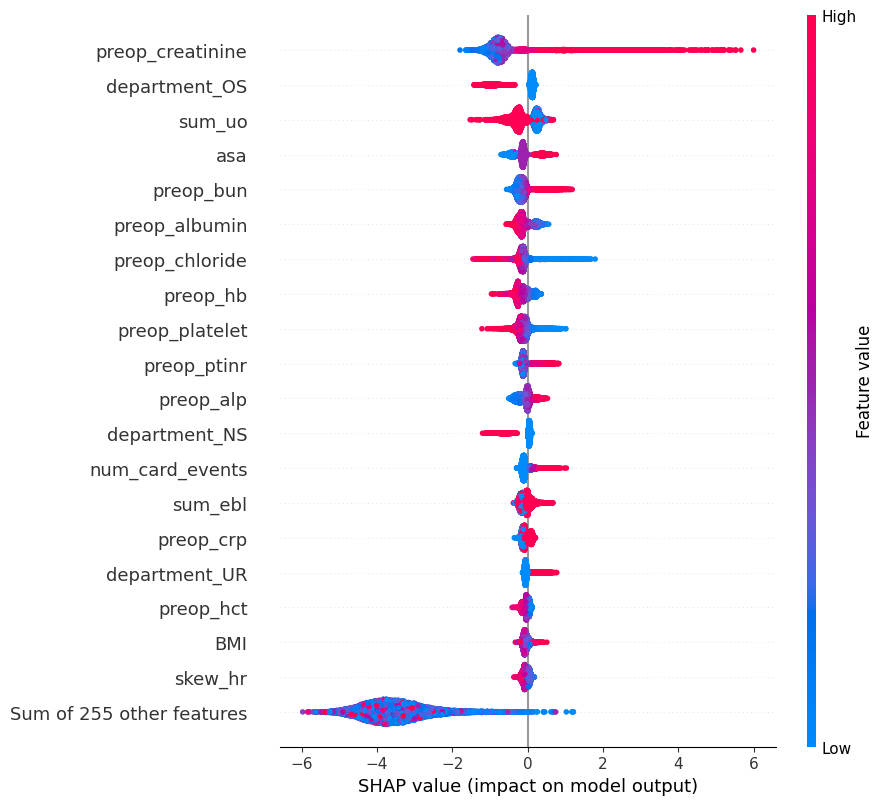

In [3]:
# =============================================================================
# Cell: Generate and Display SHAP Beeswarm Summary Plot
# =============================================================================
import os
import pickle
import shap
import matplotlib.pyplot as plt

# --- Configuration ---
# PLEASE VERIFY this path matches the results directory from your previous cells.
RESULTS_DIR = '/home/server/Projects/data/AKI/results/xgboost_analysis/'

# Number of top features you want to display on the plot
MAX_DISPLAY_FEATURES = 20

# --- File Paths ---
# Input: Path to the pickled SHAP explanation object
SHAP_VALUES_PATH = os.path.join(RESULTS_DIR, 'shap_explanation.pkl')

# --- 1. Ensure SHAP JavaScript is initialized for interactive plots ---
# This is usually done once at the beginning of the notebook.
# Running it again is harmless.
shap.initjs()

# --- 2. Load the Pre-calculated SHAP Explanation Object ---
print(f"Loading SHAP explanation object from: {SHAP_VALUES_PATH}")

if not os.path.exists(SHAP_VALUES_PATH):
    print("\nERROR: SHAP file not found.")
    print("Please ensure you have run the main analysis notebook cell first,")
    print(f"and that the RESULTS_DIR path is set correctly.")
else:
    try:
        with open(SHAP_VALUES_PATH, 'rb') as f:
            shap_explanation = pickle.load(f)
        print("SHAP explanation loaded successfully.")

        # --- 3. Generate and Display the Beeswarm Plot ---
        print(f"\nGenerating beeswarm plot for top {MAX_DISPLAY_FEATURES} features...")

        # Create a matplotlib figure to control size
        plt.figure(figsize=(12, 8))
        
        # The `show=True` default for this function will call `plt.show()`
        # which displays the plot directly in the notebook output.
        shap.plots.beeswarm(
            shap_explanation,
            max_display=MAX_DISPLAY_FEATURES
        )

    except Exception as e:
        print(f"\nAn error occurred: {e}")

# --- (Optional) 4. Save a High-Quality Copy of the Plot ---
# If you also want to save a PNG file for a presentation or paper,
# you can uncomment and run the following code in a new cell *after*
# the plot has been generated above.

# PLOT_OUTPUT_PATH = os.path.join(RESULTS_DIR, 'shap_beeswarm_summary_plot.png')
# fig = plt.gcf() # Get current figure
# fig.savefig(PLOT_OUTPUT_PATH, dpi=300, bbox_inches='tight')
# print(f"\nPlot saved to: {PLOT_OUTPUT_PATH}")
# plt.close(fig) # Close the figure to free up memory



## Waterfall

▸ Positive case 1/2 — idx 1114 — prob 0.796 — ASA 3


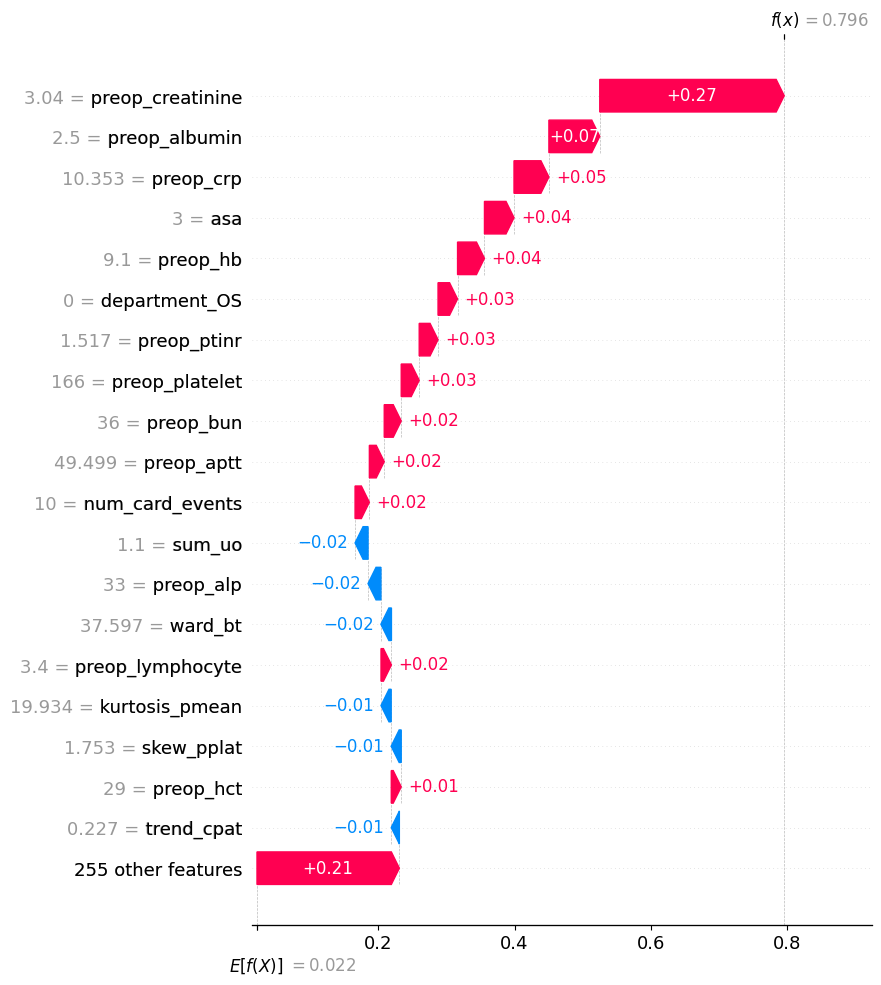

▸ Positive case 2/2 — idx 7526 — prob 0.939 — ASA 3


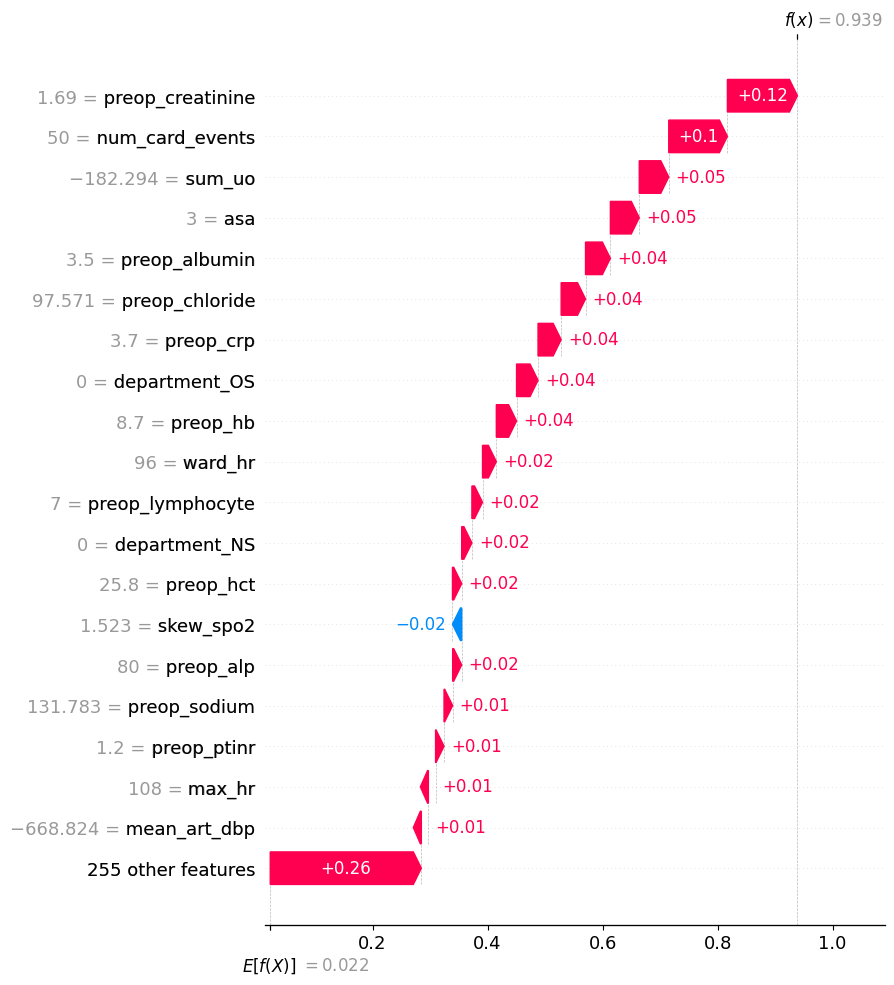

▸ Negative case 1/2 — idx 5451 — prob 0.001 — ASA 2


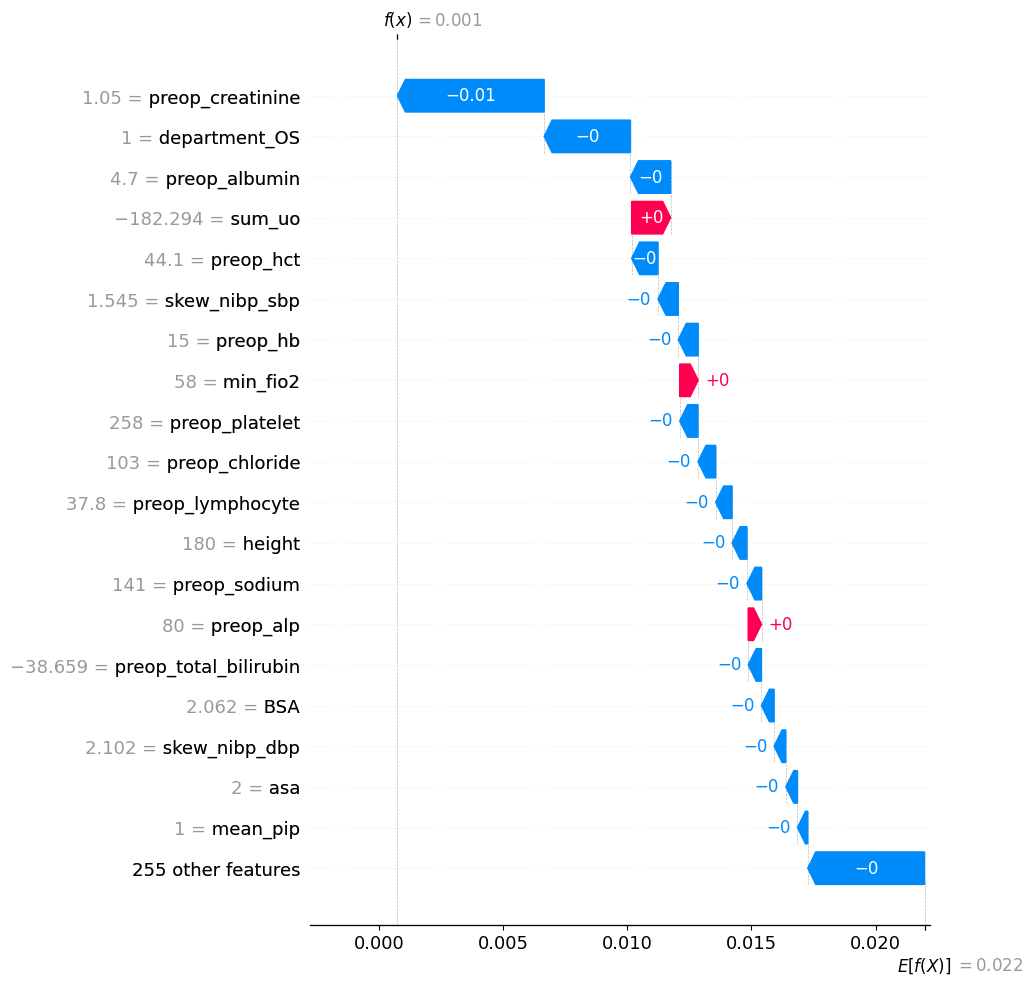

▸ Negative case 2/2 — idx 5346 — prob 0.001 — ASA 2


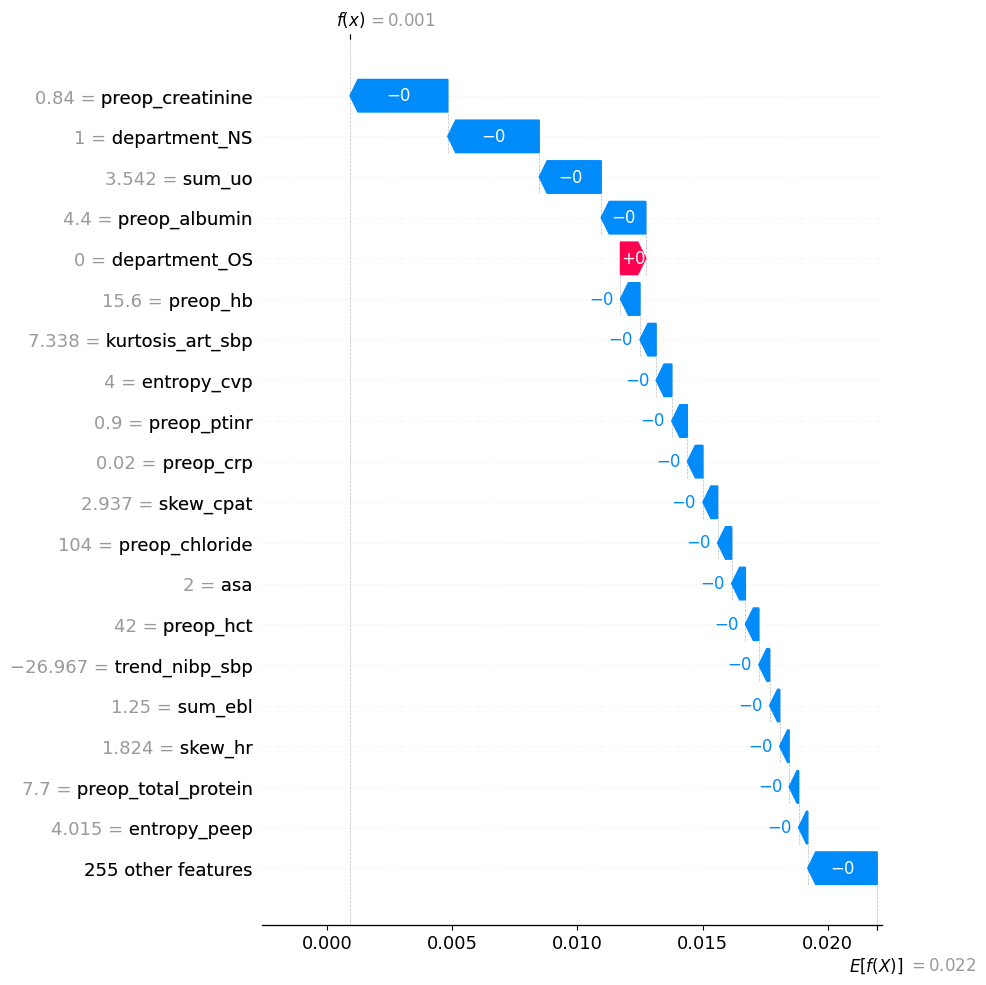

In [9]:
# =============================================================================
# Cell: Generate SHAP Waterfall Plots (Improved, Python 3.10‑compatible)
#
# Revision history
# ────────────────
# v1  2025‑07‑28 : original drop‑in replacement
# v2  2025‑07‑28 : added graceful length‑mismatch warning
# v3  2025‑07‑28 : removed multiline‑string syntax error (3.10 safe)
# v4  2025‑07‑28 : **current** – uses probability‑space SHAP (no extra sigmoid)
#                   and filters to samples whose `asa` score is a whole number.
# =============================================================================

import os
import pathlib
import pickle
import numpy as np
import pandas as pd
import shap
from scipy.special import expit  # still imported in case you revert to raw SHAP
from sklearn.model_selection import train_test_split
from typing import Optional

# ------------------- user‑settable parameters --------------------------------
DATA_PATH        = pathlib.Path(os.getenv("AKI_DATA_PATH", "/home/server/Projects/data/AKI/tabular_combined.csv"))
SHAP_PATH        = pathlib.Path(os.getenv("AKI_SHAP_PATH", "/home/server/Projects/data/AKI/results/xgboost_analysis/shap_explanation_prob.pkl"))
TARGET           = os.getenv("AKI_TARGET", "aki_boolean")
TEST_SIZE        = float(os.getenv("AKI_TEST_SIZE", "0.2"))
RANDOM_STATE     = int(os.getenv("AKI_RANDOM_STATE", "42"))
N_PER_CLASS      = int(os.getenv("AKI_N_PER_CLASS", "2"))     # plots per class
TOP_QUANTILE_ENV = os.getenv("AKI_TOP_QUANTILE", "0.25")
TOP_QUANTILE     = None if TOP_QUANTILE_ENV.lower() == "none" else float(TOP_QUANTILE_ENV)
POSITIVE_FIRST   = os.getenv("AKI_POSITIVE_FIRST", "True").lower() == "true"
ASA_COLUMN       = os.getenv("AKI_ASA_COLUMN", "asa")  # column holding ASA score
# -----------------------------------------------------------------------------

def _is_whole_number(series: pd.Series, tol: float = 1e-6) -> pd.Series:
    """Return boolean Series True where values are (approximately) integers."""
    return series.apply(lambda v: np.isclose(v % 1, 0, atol=tol))


def plot_shap_waterfalls(
    csv_path: pathlib.Path,
    shap_path: pathlib.Path,
    target: str,
    asa_column: str,
    test_size: float,
    random_state: int,
    n_per_class: int,
    top_quantile: Optional[float],
    positive_first: bool = True,
) -> None:
    """Plot SHAP waterfall charts for *n_per_class* positive and negative samples.

    Excludes any samples whose ASA score is not a whole number (e.g., 1.0, 2.0).
    Assumes *probability‑space* SHAP explanations (built with
    `TreeExplainer(model, model_output="probability")`).
    """

    # --- load artefacts ------------------------------------------------------
    if not shap_path.exists():
        raise FileNotFoundError(f"SHAP file not found: {shap_path}")
    with shap_path.open("rb") as f:
        shap_exp: shap.Explanation = pickle.load(f)

    if not csv_path.exists():
        raise FileNotFoundError(f"Data file not found: {csv_path}")
    df = pd.read_csv(csv_path)
    if "op_id" in df.columns:
        df = df.drop(columns=["op_id"])  # legacy column

    # reproduce original split ------------------------------------------------
    _, test_df = train_test_split(
        df, test_size=test_size, stratify=df[target], random_state=random_state
    )
    y_test = test_df[target].reset_index(drop=True)

    # ── ASA whole‑number mask -----------------------------------------------
    if asa_column not in test_df.columns:
        raise KeyError(f"'{asa_column}' column not found in dataset; cannot filter on ASA score.")
    asa_series = test_df[asa_column].reset_index(drop=True)
    asa_whole_mask = _is_whole_number(asa_series)

    if len(shap_exp) != len(y_test):
        msg = (
            f"\nWARNING ▶ SHAP explanations length ({len(shap_exp)}) does not match "
            f"y_test length ({len(y_test)}).\n\n"
            "This usually indicates that the dataset used when generating the SHAP file "
            "isn't the same as the one loaded here.\n\n"
            "Quick checklist:\n"
            "  • TEST_SIZE and RANDOM_STATE identical to training?\n"
            "  • Any rows/columns dropped before shap.save?\n"
            "  • Did you filter the test set (e.g. only positives) before saving?\n\n"
            "➡ Fix one of the above and re‑run, or regenerate the SHAP file with the current split."
        )
        print(msg)
        return

    # probability space → no sigmoid ----------------------------------------
    y_prob = shap_exp.base_values + shap_exp.values.sum(axis=1)

    # determine plotting order ------------------------------------------------
    class_order = [(1, "Positive"), (0, "Negative")]
    if not positive_first:
        class_order.reverse()

    rng = np.random.default_rng(random_state)

    for label, label_name in class_order:
        mask = (y_test == label) & asa_whole_mask
        if top_quantile is not None:
            threshold = np.quantile(
                y_prob[mask] if label else 1 - y_prob[mask],
                1 - top_quantile,
            )
            mask &= (y_prob >= threshold) if label else (y_prob <= 1 - threshold)

        pool = np.flatnonzero(mask)
        if pool.size == 0:
            print(f"No {label_name.lower()} cases with whole‑number ASA found after filtering.")
            continue

        chosen = rng.choice(pool, size=min(n_per_class, pool.size), replace=False)

        for i, idx in enumerate(chosen, 1):
            print(
                f"▸ {label_name} case {i}/{n_per_class} — idx {idx} — prob {y_prob[idx]:.3f} "
                f"— ASA {asa_series[idx]:.0f}"
            )
            shap.plots.waterfall(shap_exp[idx], max_display=20)


# ------------------- Execute --------------------------------------------------
plot_shap_waterfalls(
    csv_path=DATA_PATH,
    shap_path=SHAP_PATH,
    target=TARGET,
    asa_column=ASA_COLUMN,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    n_per_class=N_PER_CLASS,
    top_quantile=TOP_QUANTILE,
    positive_first=POSITIVE_FIRST,
)


## Scatter Plot

In [4]:
# =============================================================================
# Cell 1: Notebook Setup and Configuration
#
# Description:
# This cell imports all necessary libraries and defines the configuration
# variables for the analysis. Edit the variables in the 'Configuration'
# section to match your environment and analysis needs.
# =============================================================================
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from sklearn.model_selection import train_test_split
import re

# --- Configuration ---
# PLEASE VERIFY these paths match your environment.
BASE_DATA_DIR = '/home/server/Projects/data/AKI/'
RESULTS_DIR = os.path.join(BASE_DATA_DIR, 'results/xgboost_analysis/')
OUTPUT_DIR = 'figures/scatters' # Directory to save plots

# --- File Paths ---
DATA_PATH = os.path.join(BASE_DATA_DIR, 'tabular_combined.csv')
SHAP_VALUES_DENORM_PATH = os.path.join(RESULTS_DIR, 'shap_explanation_denorm.pkl')

# --- Model & Plotting Parameters ---
PLOTTING_ENABLED = True # <<< SET TO False TO DISABLE PLOT GENERATION
TARGET = 'aki_boolean'
RANDOM_STATE = 42
DPI = 400 # DPI for saved figures

# Set MAX_PLOTS to a number to limit the output (e.g., 10).
# Set to None to plot all features.
MAX_PLOTS = None


# =============================================================================
# Cell 2: Helper Function for Plotting
#
# Description:
# This cell contains the function responsible for generating a single
# SHAP interaction plot for a given feature. The plot is saved to a file
# with styling suitable for publications.
# =============================================================================
def plot_and_save_shap_interaction(shap_explanation, feature_name, y_true, output_dir):
    """
    Generates and saves a publication-ready SHAP interaction plot.

    This plot shows the feature's value vs. its SHAP value. Points are colored
    by the true outcome (e.g., AKI Positive/Negative). A trendline is fitted
    to show the general relationship.

    Args:
        shap_explanation (shap.Explanation): The SHAP explanation object.
        feature_name (str): The name of the feature to plot.
        y_true (pd.Series or np.ndarray): A boolean array of true outcomes.
        output_dir (str): The directory where the plot image will be saved.
    """
    # Sanitize feature name for use in the filename
    safe_feature_name = re.sub(r'[^a-zA-Z0-9_-]', '_', feature_name)
    print(f"--- Plotting interaction for: {feature_name} ---")
    
    # Use a publication-ready style context
    with plt.style.context('seaborn-v0_8-paper'):
        fig, ax = plt.subplots(figsize=(8, 6))

        try:
            # --- 1. Extract Data for Plotting ---
            feature_index = list(shap_explanation.feature_names).index(feature_name)
            shap_vals = shap_explanation.values[:, feature_index]
            feature_vals = shap_explanation.data[:, feature_index]

            # --- 2. Create the Scatter Plot ---
            ax.scatter(feature_vals[~y_true], shap_vals[~y_true], s=15, zorder=3, 
                       color='royalblue', alpha=0.6, label='AKI Negative')
            ax.scatter(feature_vals[y_true], shap_vals[y_true], s=15, zorder=3, 
                       color='crimson', alpha=0.6, label='AKI Positive')

            # --- 3. Calculate and Plot Trendline ---
            valid_indices = ~np.isnan(feature_vals) & ~np.isnan(shap_vals)
            if np.any(valid_indices):
                slope, intercept, _, _, _ = linregress(feature_vals[valid_indices], shap_vals[valid_indices])
                min_x, max_x = np.nanmin(feature_vals), np.nanmax(feature_vals)
                trend_x = np.linspace(min_x, max_x, 100)
                trendline = slope * trend_x + intercept

                if abs(slope) > 1e-4:
                    x_intercept = -intercept / slope
                    label = f'Trendline (Slope: {slope:.2g}, X-Intercept: {x_intercept:.2f})'
                else:
                    label = f'Trendline (Slope: {slope:.2g})'
                
                ax.plot(trend_x, trendline, color='black', label=label, lw=2.5, zorder=5)

            # --- 4. Finalize and Save Plot (Publication Styling) ---
            font_settings = {'fontsize': 14, 'fontweight': 'bold'}
            ax.set_xlabel(f"Feature Value: {feature_name}", **font_settings)
            ax.set_ylabel(f"SHAP Value for {feature_name}", **font_settings)
            ax.set_title(f"SHAP Interaction Plot for {feature_name}", fontsize=16, fontweight='bold', pad=20)

            ax.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
            ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

            ax.grid(False)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_linewidth(1.5)
            ax.spines['bottom'].set_linewidth(1.5)

            ax.legend(fontsize=12, loc='best')
            plt.tight_layout()

            # For vector graphics (ideal for publications), change file extension to .svg or .pdf
            filename = f"{safe_feature_name}_interaction_plot.png"
            filepath = os.path.join(output_dir, filename)
            plt.savefig(filepath, dpi=DPI, bbox_inches='tight')

        except Exception as e:
            print(f"An unexpected error occurred while plotting '{feature_name}': {e}")
        finally:
            plt.close(fig)


# =============================================================================
# Cell 3: Load Data and SHAP Object
#
# Description:
# This cell loads the pre-computed SHAP explanation object. It then reloads
# the original dataset and performs the *exact same* train-test split to
# retrieve the outcome labels (y_test) corresponding to the SHAP values.
# =============================================================================
print(f"Loading SHAP explanation object from: {SHAP_VALUES_DENORM_PATH}")
if not os.path.exists(SHAP_VALUES_DENORM_PATH):
    raise FileNotFoundError(f"SHAP file not found at {SHAP_VALUES_DENORM_PATH}. Please ensure the file exists.")

with open(SHAP_VALUES_DENORM_PATH, 'rb') as f:
    shap_explanation = pickle.load(f)
print("SHAP explanation loaded successfully.")

# Reload original data to get the y_test labels needed for coloring the plots
print(f"\nReloading data from {DATA_PATH} to get test set labels...")
df = pd.read_csv(DATA_PATH)
if 'op_id' in df.columns:
    df = df.drop(columns=['op_id'])

# Perform the exact same stratified split as in the original analysis
print("Performing train-test split to align with SHAP values...")
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df[TARGET],
    random_state=RANDOM_STATE
)
y_test = test_df[TARGET].astype(bool)
print("Test set labels (y_test) successfully isolated.")


# =============================================================================
# Cell 4: Generate and Save All Plots
#
# Description:
# This cell checks if plotting is enabled. If so, it creates the output
# directory and iterates through the features to create and save the plots.
# =============================================================================
if PLOTTING_ENABLED:
    # Create the output directory if it doesn't exist
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f"\nPlots will be saved to: '{os.path.abspath(OUTPUT_DIR)}'")

    all_feature_names = shap_explanation.feature_names
    
    if MAX_PLOTS is not None and MAX_PLOTS < len(all_feature_names):
        features_to_plot = all_feature_names[:MAX_PLOTS]
        print(f"\nGenerating plots for the first {MAX_PLOTS} features.")
    else:
        features_to_plot = all_feature_names
        print(f"\nGenerating plots for all {len(all_feature_names)} features.")
    
    # Loop through the features and generate a plot for each one
    for feature_name in features_to_plot:
        plot_and_save_shap_interaction(
            shap_explanation,
            feature_name,
            y_test.values,
            OUTPUT_DIR
        )

    print(f"\n\n--- Plot generation complete. {len(features_to_plot)} plots saved. ---")
else:
    print("\n\n--- Plotting is disabled by the PLOTTING_ENABLED flag. Skipping plot generation. ---")

print("\n--- Notebook execution finished. ---")


Loading SHAP explanation object from: /home/server/Projects/data/AKI/results/xgboost_analysis/shap_explanation_denorm.pkl
SHAP explanation loaded successfully.

Reloading data from /home/server/Projects/data/AKI/tabular_combined.csv to get test set labels...
Performing train-test split to align with SHAP values...
Test set labels (y_test) successfully isolated.

Plots will be saved to: '/home/server/Projects/VitalDB-Dimensionality-Reduction/create_results/figures/scatters'

Generating plots for all 274 features.
--- Plotting interaction for: age ---
--- Plotting interaction for: sex ---
--- Plotting interaction for: height ---
--- Plotting interaction for: weight ---
--- Plotting interaction for: asa ---
--- Plotting interaction for: emop ---
--- Plotting interaction for: BSA ---
--- Plotting interaction for: BMI ---
--- Plotting interaction for: booking_case_length ---
--- Plotting interaction for: num_card_events ---
--- Plotting interaction for: op_len ---
--- Plotting interaction f

## Partial Dependence Plot 

In [5]:
# =============================================================================
# Cell 1: Notebook Setup and Configuration
#
# Description:
# This cell imports all necessary libraries and defines the configuration
# variables for the analysis. Edit the variables in the 'Configuration'
# section to match your environment and analysis needs.
# =============================================================================
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from sklearn.model_selection import train_test_split
from itertools import combinations
import re

# --- Configuration ---
# PLEASE VERIFY these paths match your environment.
BASE_DATA_DIR = '/home/server/Projects/data/AKI/'
RESULTS_DIR = os.path.join(BASE_DATA_DIR, 'results/xgboost_analysis/')
OUTPUT_DIR = 'figures/cross_scatters' # Directory to save plots

# --- File Paths ---
DATA_PATH = os.path.join(BASE_DATA_DIR, 'tabular_combined.csv')
SHAP_VALUES_DENORM_PATH = os.path.join(RESULTS_DIR, 'shap_explanation_denorm.pkl')

# --- Model & Plotting Parameters ---
PLOTTING_ENABLED = True # <<< SET TO False TO DISABLE PLOT GENERATION
TARGET = 'aki_boolean'
RANDOM_STATE = 42
DPI = 400 # DPI for saved figures

# Set MAX_FEATURES_FOR_INTERACTION to limit the number of features to pair up.
# For example, 10 features will produce (10*9)/2 = 45 plots.
# Set to None to plot interactions for all features.
MAX_FEATURES_FOR_INTERACTION = None


# =============================================================================
# Cell 2: Helper Function for Plotting
#
# Description:
# This cell contains the function responsible for generating a single
# SHAP dependence plot for a given pair of features, showing their interaction.
# The plot is saved to a file instead of being displayed.
# =============================================================================
def plot_and_save_shap_dependence(shap_explanation, main_feature, interaction_feature, output_dir):
    """
    Generates and saves a SHAP dependence plot for a pair of features.

    This plot shows the main feature's value vs. its SHAP value. Points are colored
    by the value of the interaction feature to show interaction effects.

    Args:
        shap_explanation (shap.Explanation):
            The SHAP explanation object.
        main_feature (str):
            The name of the feature for the X-axis and SHAP values.
        interaction_feature (str):
            The name of the feature to color the points by.
        output_dir (str):
            The directory where the plot image will be saved.
    """
    # Sanitize feature names for use in filenames
    safe_main_feature = re.sub(r'[^a-zA-Z0-9_-]', '_', main_feature)
    safe_interaction_feature = re.sub(r'[^a-zA-Z0-9_-]', '_', interaction_feature)
    
    print(f"--- Plotting: {main_feature} (SHAP) vs. {interaction_feature} (Color) ---")
    
    fig, ax = plt.subplots(figsize=(10, 6))

    try:
        # --- 1. Extract Data for Plotting ---
        feature_names = list(shap_explanation.feature_names)
        main_feature_index = feature_names.index(main_feature)
        interaction_feature_index = feature_names.index(interaction_feature)

        main_feature_vals = shap_explanation.data[:, main_feature_index]
        shap_vals = shap_explanation.values[:, main_feature_index]
        interaction_vals = shap_explanation.data[:, interaction_feature_index]

        # --- 2. Create the Scatter Plot ---
        # Use a color map to show the interaction feature's effect
        scatter = ax.scatter(main_feature_vals, shap_vals, s=10, zorder=3,
                             c=interaction_vals, cmap='viridis', alpha=0.7)
        
        # Add a colorbar to explain the coloring
        cbar = fig.colorbar(scatter, ax=ax)
        cbar.set_label(f'Interaction Feature: {interaction_feature}', fontsize=12)

        # --- 3. Finalize and Save Plot ---
        ax.grid(True, which='both', linestyle='--', linewidth=0.5, zorder=0)
        ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax.set_xlabel(f"Feature Value: {main_feature}", fontsize=12)
        ax.set_ylabel(f"SHAP Value for {main_feature}", fontsize=12)
        ax.set_title(f"SHAP Dependence Plot: {main_feature} vs. {interaction_feature}", fontsize=14)

        # Construct file path and save the figure
        filename = f"{safe_main_feature}_vs_{safe_interaction_feature}_interaction.png"
        filepath = os.path.join(output_dir, filename)
        plt.savefig(filepath, dpi=DPI, bbox_inches='tight')

    except Exception as e:
        print(f"An unexpected error occurred while plotting '{main_feature}' vs '{interaction_feature}': {e}")
    finally:
        plt.close(fig) # Close the figure to free memory


# =============================================================================
# Cell 3: Load Data and SHAP Object
#
# Description:
# This cell loads the pre-computed SHAP explanation object. It's kept separate
# for clarity. The logic to reload original data is kept in case it's needed
# for other validation steps, but is not used for the dependence plots.
# =============================================================================
print(f"Loading SHAP explanation object from: {SHAP_VALUES_DENORM_PATH}")
if not os.path.exists(SHAP_VALUES_DENORM_PATH):
    raise FileNotFoundError(f"SHAP file not found at {SHAP_VALUES_DENORM_PATH}. Please ensure the file exists.")

with open(SHAP_VALUES_DENORM_PATH, 'rb') as f:
    shap_explanation = pickle.load(f)
print("SHAP explanation loaded successfully.")

# The y_test object is not needed for dependence plots but is kept for context
print(f"\nReloading data from {DATA_PATH} to get test set labels...")
df = pd.read_csv(DATA_PATH)
if 'op_id' in df.columns:
    df = df.drop(columns=['op_id'])
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df[TARGET], random_state=RANDOM_STATE)
y_test = test_df[TARGET].astype(bool)
print("Test set labels (y_test) loaded.")


# =============================================================================
# Cell 4: Generate and Save All Plots
#
# Description:
# This cell checks if plotting is enabled. If so, it creates the output
# directory, generates all unique pairs of features, and then iterates
# through them to create and save the SHAP dependence plots.
# =============================================================================
if PLOTTING_ENABLED:
    # Create the output directory if it doesn't exist
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f"\nPlots will be saved to: '{os.path.abspath(OUTPUT_DIR)}'")

    all_feature_names = shap_explanation.feature_names

    if MAX_FEATURES_FOR_INTERACTION is not None and MAX_FEATURES_FOR_INTERACTION < len(all_feature_names):
        features_to_plot = all_feature_names[:MAX_FEATURES_FOR_INTERACTION]
        print(f"\nGenerating interaction plots for the first {MAX_FEATURES_FOR_INTERACTION} features.")
    else:
        features_to_plot = all_feature_names
        print(f"\nGenerating interaction plots for all {len(all_feature_names)} features.")

    # Generate unique pairs of features using itertools.combinations
    feature_pairs = list(combinations(features_to_plot, 2))
    print(f"Found {len(feature_pairs)} unique feature pairs to plot.")

    # Loop through the unique pairs and generate a plot for each
    for main_feature, interaction_feature in feature_pairs:
        plot_and_save_shap_dependence(
            shap_explanation,
            main_feature,
            interaction_feature,
            OUTPUT_DIR
        )
        # We also plot the reverse interaction
        plot_and_save_shap_dependence(
            shap_explanation,
            interaction_feature,
            main_feature,
            OUTPUT_DIR
        )

    print(f"\n\n--- Plot generation complete. {len(feature_pairs) * 2} plots saved. ---")
else:
    print("\n\n--- Plotting is disabled by the PLOTTING_ENABLED flag. Skipping plot generation. ---")

print("\n--- Notebook execution finished. ---")


Loading SHAP explanation object from: /home/server/Projects/data/AKI/results/xgboost_analysis/shap_explanation_denorm.pkl
SHAP explanation loaded successfully.

Reloading data from /home/server/Projects/data/AKI/tabular_combined.csv to get test set labels...
Test set labels (y_test) loaded.

Plots will be saved to: '/home/server/Projects/VitalDB-Dimensionality-Reduction/create_results/figures/cross_scatters'

Generating interaction plots for all 274 features.
Found 37401 unique feature pairs to plot.
--- Plotting: age (SHAP) vs. sex (Color) ---
--- Plotting: sex (SHAP) vs. age (Color) ---
--- Plotting: age (SHAP) vs. height (Color) ---
--- Plotting: height (SHAP) vs. age (Color) ---
--- Plotting: age (SHAP) vs. weight (Color) ---
--- Plotting: weight (SHAP) vs. age (Color) ---


KeyboardInterrupt: 